### Сводный отчет по анализу

In [ ]:
# Настройка путей
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

#### Импорт библиотек и загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query

# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])


In [3]:
# Установка стиля для графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# sns.set_theme(style="whitegrid")

In [4]:
df.head()

,transaction_id,customer_id,sale_date,sale_time,day_of_week,day_name,is_weekend,coffee_name,drink_price,total_cost,payment_method,datetime,time_of_day
0,TX_0125,CUST_6596,2025-07-01,08:24:55,2,Tuesday,False,Cappuccino,320.0,640.0,card,2025-07-01 08:24:55,Morning
1,TX_0125,CUST_6596,2025-07-01,08:24:55,2,Tuesday,False,Cappuccino,320.0,640.0,card,2025-07-01 08:24:55,Morning
2,TX_1977,CUST_4044,2025-07-01,08:42:32,2,Tuesday,False,Latte,340.0,340.0,card,2025-07-01 08:42:32,Morning
3,TX_3011,CUST_2256,2025-07-01,08:43:55,2,Tuesday,False,Latte with add,440.0,440.0,cash,2025-07-01 08:43:55,Morning
4,TX_3392,CUST_6082,2025-07-01,08:44:55,2,Tuesday,False,Latte with add,440.0,760.0,card,2025-07-01 08:44:55,Morning


#### 1.  Базовая информация о данных

In [5]:
# Размер датасета
print(f"Размер датасета: {df.shape}")

# Общая информация
print(df.info())

# Статистическое описание числовых колонок
print(df.describe())

# Статистическое описание категориальных колонок
print(df.describe(include=['object']))

Размер датасета: (4943, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  4943 non-null   object        
 1   customer_id     4943 non-null   object        
 2   sale_date       4943 non-null   datetime64[ns]
 3   sale_time       4943 non-null   object        
 4   day_of_week     4943 non-null   int64         
 5   day_name        4943 non-null   object        
 6   is_weekend      4943 non-null   bool          
 7   coffee_name     4943 non-null   object        
 8   drink_price     4943 non-null   float64       
 9   total_cost      4943 non-null   float64       
 10  payment_method  4943 non-null   object        
 11  datetime        4943 non-null   datetime64[ns]
 12  time_of_day     4943 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 468

#### 2. Проверка качества данных (пропуски, дубликаты)

In [6]:
# Пропущенные значения
print("Пропущенные значения:")
print(df.isnull().sum())

# Дубликаты (полные строки)
print(f"\nКоличество дубликатов: {df.duplicated().sum()}")

# Удаление дубликатов, если нужно (можно раскомментировать)
# df = df.drop_duplicates()

# Проверка уникальных значений в ключевых колонках
print("\nУникальные напитки:")
print(df['coffee_name'].value_counts().head(10))

Пропущенные значения:
transaction_id    0
customer_id       0
sale_date         0
sale_time         0
day_of_week       0
day_name          0
is_weekend        0
coffee_name       0
drink_price       0
total_cost        0
payment_method    0
datetime          0
time_of_day       0
dtype: int64

Количество дубликатов: 276

Уникальные напитки:
coffee_name
Cappuccino              1165
Latte                   1042
Batch brew               844
Latte with add           743
Raf coffee               342
Flat white               335
Warming drinks (tea)     267
Espresso                 205
Name: count, dtype: int64


#### 3. Преобразование дат (для временного анализа)

In [7]:
# Добавление месяца и часа (если нужно для группировки)
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date
display(df[['datetime', 'month', 'hour', 'date']].head())

,datetime,month,hour,date
0,2025-07-01 08:24:55,7,8,2025-07-01
1,2025-07-01 08:24:55,7,8,2025-07-01
2,2025-07-01 08:42:32,7,8,2025-07-01
3,2025-07-01 08:43:55,7,8,2025-07-01
4,2025-07-01 08:44:55,7,8,2025-07-01


In [8]:
print(df.columns.tolist())

['transaction_id', 'customer_id', 'sale_date', 'sale_time', 'day_of_week', 'day_name', 'is_weekend', 'coffee_name', 'drink_price', 'total_cost', 'payment_method', 'datetime', 'time_of_day', 'month', 'hour', 'date']


#### Структура данных:

- **Каждая строка = 1 напиток**

- **Каждая транзакция (`transaction_id`) = 1 заказ (чек)**

- `total_cost` — **одинаков** для всех строк одной транзакции

- **Все расчёты по чекам, выручке, времени, дням — только по уникальным `transaction_id`**

In [9]:
# Создание df_tx — только уникальные транзакции
df_tx = df.drop_duplicates(subset='transaction_id').reset_index(drop=True)

# Добавляем количество напитков в заказе
df_tx['num_drinks'] = df.groupby('transaction_id').size().values

print(f"Уникальных транзакций: {len(df_tx)}")
print(f"Всего строк в df: {len(df)}")
print(f"Среднее количество напитков в заказе: {df_tx['num_drinks'].mean():.2f}")

Уникальных транзакций: 3547
Всего строк в df: 4943
Среднее количество напитков в заказе: 1.39


#### 4. Визуализация распределения цен (drink_price и total_cost)

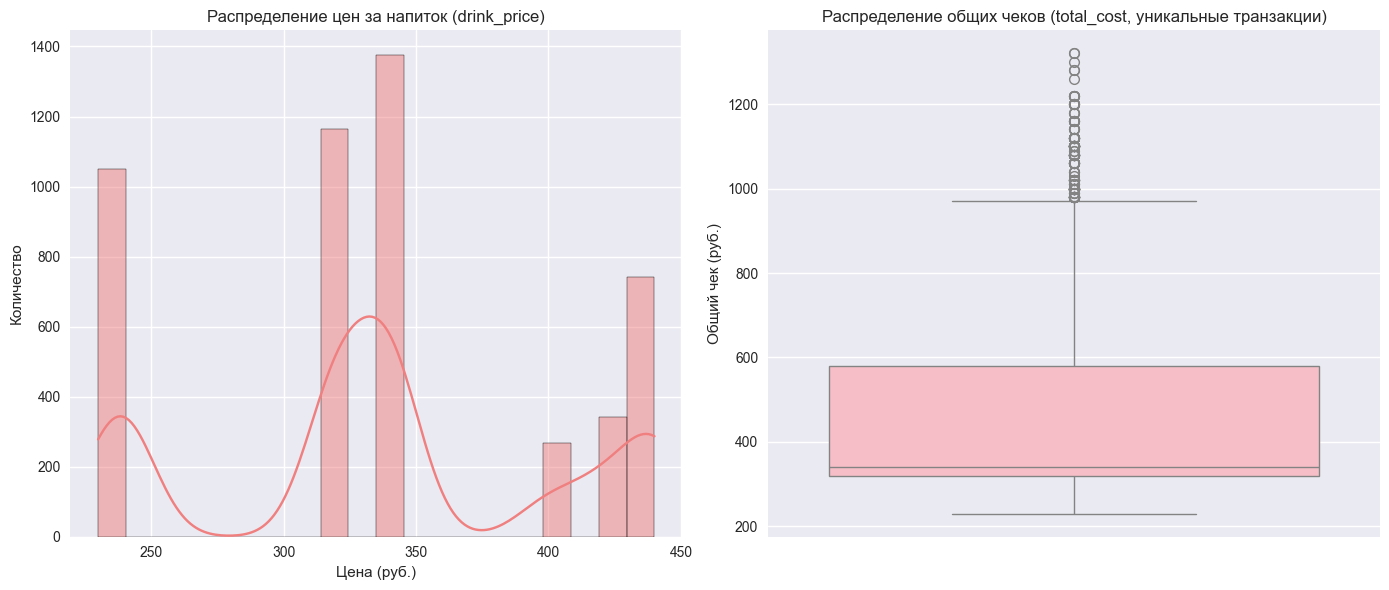

Средняя цена напитка: 337.46 руб.
Средний чек (по транзакциям): 470.27 руб.
Медиана чека: 340.00 руб.
Q1: 320.00, Q3: 580.00


In [10]:
# Подготовка данных
drink_prices = df['drink_price']
unique_checks = df_tx['total_cost']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Гистограмма цен за напиток
sns.histplot(drink_prices, kde=True, ax=axes[0], color='lightcoral', bins=20)
axes[0].set_title('Распределение цен за напиток (drink_price)')
axes[0].set_xlabel('Цена (руб.)')
axes[0].set_ylabel('Количество')

# 2. Boxplot чеков (уникальные транзакции)
sns.boxplot(y=unique_checks, ax=axes[1], color='lightpink')
axes[1].set_title('Распределение общих чеков (total_cost, уникальные транзакции)')
axes[1].set_ylabel('Общий чек (руб.)')

plt.tight_layout()
plt.show()

# Статистика
print(f"Средняя цена напитка: {drink_prices.mean():.2f} руб.")
print(f"Средний чек (по транзакциям): {unique_checks.mean():.2f} руб.")
print(f"Медиана чека: {unique_checks.median():.2f} руб.")
print(f"Q1: {unique_checks.quantile(0.25):.2f}, Q3: {unique_checks.quantile(0.75):.2f}")


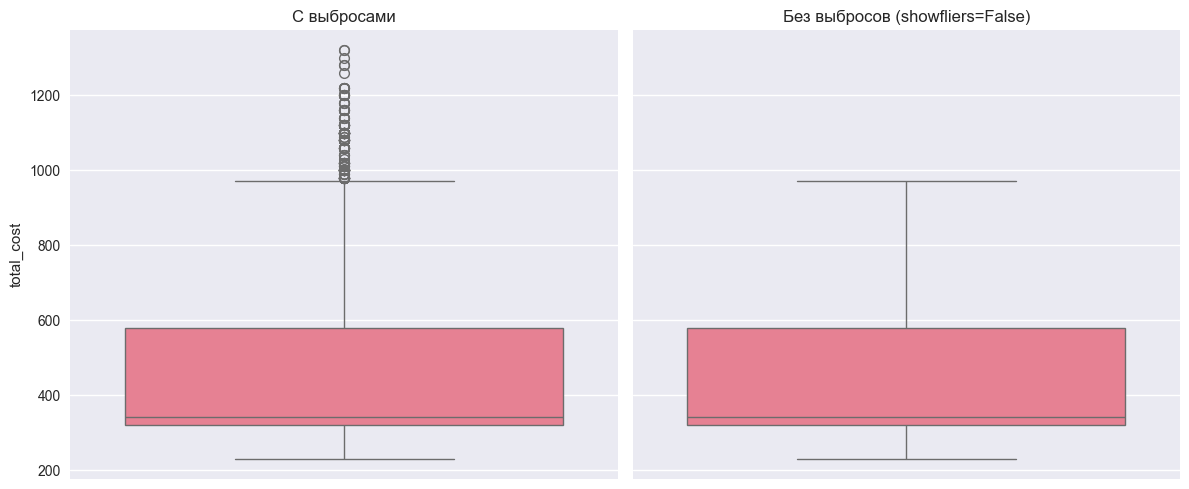

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.boxplot(y=unique_checks, ax=ax1)
ax1.set_title('С выбросами')

sns.boxplot(y=unique_checks, ax=ax2, showfliers=False)
ax2.set_title('Без выбросов (showfliers=False)')

plt.tight_layout()
plt.show()

In [12]:
# Статистика выбросов
iqr = unique_checks.quantile(0.75) - unique_checks.quantile(0.25)
q1 = unique_checks.quantile(0.25)
q3 = unique_checks.quantile(0.75)
upper_fence = q3 + 1.5 * iqr
outliers = unique_checks[unique_checks > upper_fence]

print(f"Верхняя граница (Q3 + 1.5×IQR): {upper_fence:.2f} (руб.)")
print(f"Количество выбросов: {len(outliers)} из {len(unique_checks)}")
print(f"Максимальный чек: {unique_checks.max():.2f} (руб.)")

Верхняя граница (Q3 + 1.5×IQR): 970.00 (руб.)
Количество выбросов: 226 из 3547
Максимальный чек: 1320.00 (руб.)


>Q1 = 320
>
>Q3 = 580
>
>IQR = 580 - 320 = 260
>
>**upper_bound** = Q3 + 1.5 * IQR = 580 + 390 = 970

In [13]:
unique_checks.describe()

count    3547.000000
mean      470.270651
std       233.525507
min       230.000000
25%       320.000000
50%       340.000000
75%       580.000000
max      1320.000000
Name: total_cost, dtype: float64

#### 5.  Продажи по времени дня (time_of_day)

,time_of_day,num_transactions,total_revenue,avg_check
0,Morning,1175,558610.0,475.41
1,Afternoon,1918,891450.0,464.78
2,Evening,453,217550.0,480.24
3,Outside hours,1,440.0,440.00


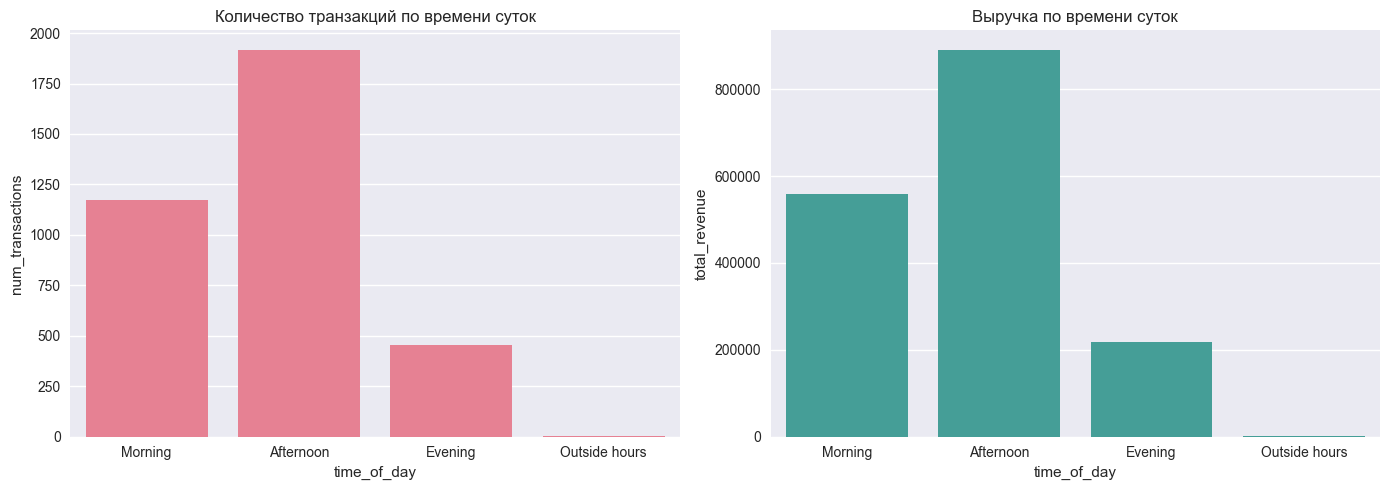

In [14]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Outside hours']

# Преобразуем в упорядоченную категорию 
df_tx['time_of_day'] = pd.Categorical(
    df_tx['time_of_day'],
    categories=time_order,
    ordered=True
)

time_sales = (
    df_tx
    .groupby('time_of_day', observed=True)
    .agg(
        num_transactions=('transaction_id', 'count'),   
        total_revenue=('total_cost', 'sum'),
        avg_check=('total_cost', 'mean')
    )
    .round(2)
    .reset_index()  
)

display(time_sales)

husl_colors = sns.color_palette("husl", n_colors=4) 
color_count = husl_colors[0]  
color_revenue = husl_colors[2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

sns.barplot(
    data=time_sales,
    x='time_of_day',
    y='num_transactions',
    order=time_order,
    ax=ax1,
    color=color_count  
)
ax1.set_title('Количество транзакций по времени суток')

sns.barplot(
    data=time_sales,
    x='time_of_day',
    y='total_revenue',
    order=time_order,
    ax=ax2,
    color=color_revenue  
)
ax2.set_title('Выручка по времени суток')

plt.tight_layout()
plt.show()

#### Выручка по часам

In [15]:
hourly_stats = (
    df_tx
    .groupby('hour')
    .agg(
        num_tx=('transaction_id', 'count'),
        total_revenue=('total_cost', 'sum'),
        avg_check=('total_cost', 'mean')
    )
    .round(2)
)

print(hourly_stats)

      num_tx  total_revenue  avg_check
hour                                  
8        299       145040.0     485.08
9        557       263820.0     473.64
10       319       149750.0     469.44
11       103        52650.0     511.17
12       430       195630.0     454.95
13       895       416210.0     465.04
14       433       201050.0     464.32
15        57        25910.0     454.56
16        39        19800.0     507.69
17       173        80740.0     466.71
18       193        95220.0     493.37
19        48        21790.0     453.96
20         1          440.0     440.00


#### 6. Топ-кофе по популярности и выручке

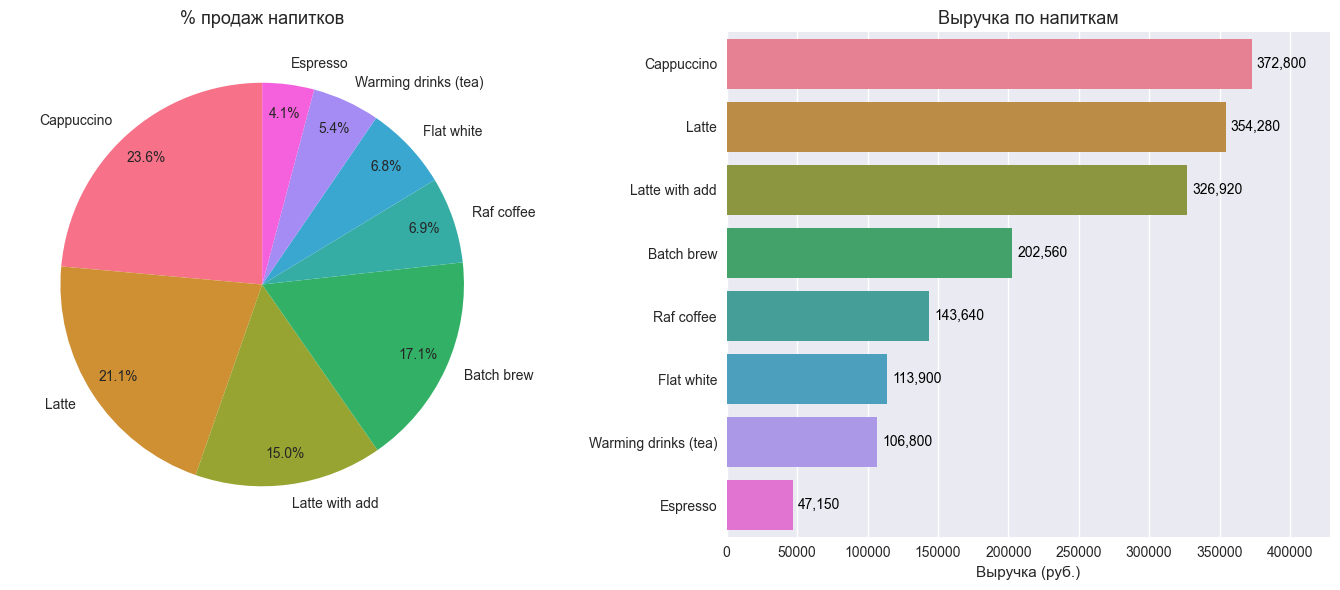

In [16]:
# Подготовка данных 
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = sns.color_palette("husl", n_colors=len(coffee_stats))
ax1.pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85
)
ax1.set_title('% продаж напитков', fontsize=13)

# Bar chart
sns.barplot(
    data=coffee_stats,
    x='revenue',
    y='coffee_name',
    hue='coffee_name',       
    palette="husl",
    dodge=False,
    legend=False,            
    ax=ax2
)
ax2.set_xlabel('Выручка (руб.)', fontsize=11)
ax2.set_ylabel('')
ax2.set_title('Выручка по напиткам', fontsize=13)

max_revenue = coffee_stats['revenue'].max() 
ax2.set_xlim(0, max_revenue * 1.15)

for i, v in enumerate(coffee_stats['revenue']):
    ax2.text(v + max_revenue * 0.01, i, f'{int(v):,}',
             va='center', ha='left', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [17]:
coffee_revenue = (
    df
    .groupby('coffee_name', as_index=False)
    .agg(revenue=('drink_price', 'sum'),
        quantity=('coffee_name', 'count'))
    .sort_values('revenue', ascending=False)
    .head(8)
)

# Топ по выручке
fig = px.bar(
    coffee_revenue,
    x='coffee_name',
    y='revenue',
    title='Рейтинг напитков по выручке',
    labels={'coffee_name': 'Напиток', 'revenue': 'Выручка (₽)'},
    color='revenue',
    color_continuous_scale='Tealgrn'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

#### 7. Анализ по дням недели (is_weekend и day_name)

Выручка по дням недели:
           total_orders   revenue  avg_ticket
day_name                                     
Tuesday             538  253610.0      471.39
Saturday            517  253350.0      490.04
Thursday            524  247560.0      472.44
Wednesday           486  233870.0      481.21
Friday              496  230880.0      465.48
Monday              492  229420.0      466.30
Sunday              494  219360.0      444.05


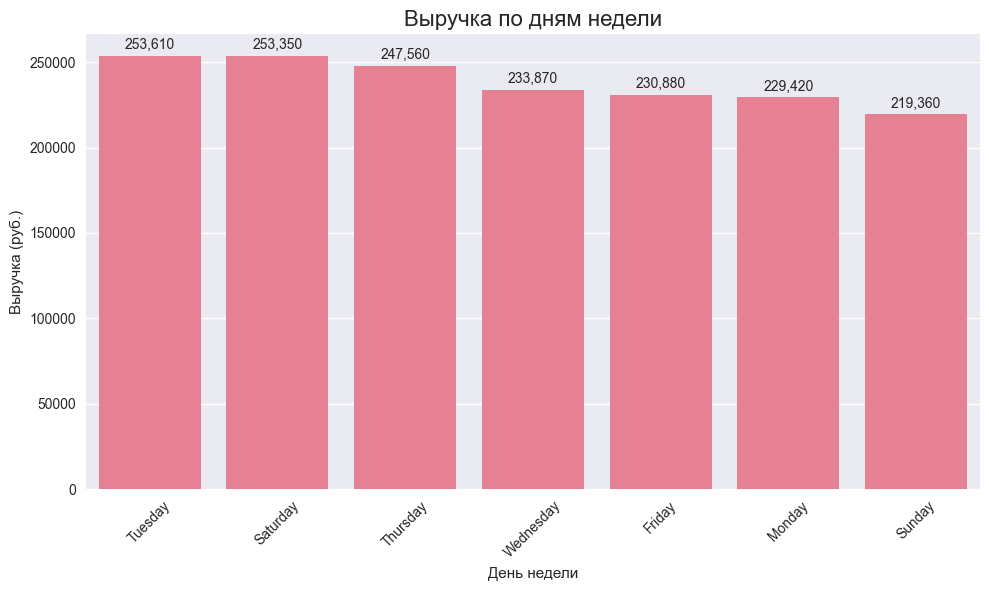


 Weekend vs Weekday:
            total_orders    revenue  avg_ticket
is_weekend                                     
Weekday             2536  1195340.0      471.35
Weekend             1011   472710.0      467.57


In [18]:
# Динамика по дням недели
day_stats = (
    df_tx
    .groupby('day_name', observed=False)
    .agg(
        total_orders=('transaction_id', 'count'),
        revenue=('total_cost', 'sum'),
        avg_ticket=('total_cost', 'mean'),
    )
    .round(2)
    .sort_values('revenue', ascending=False)
)

print("Выручка по дням недели:")
print(day_stats)
# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    data=day_stats.reset_index(),
    x='day_name',
    y='revenue',
    ax=ax,
    errorbar=None
)

# Подписи значений
for i, (_, row) in enumerate(day_stats.iterrows()):
    ax.text(i, row['revenue'] + row['revenue'] * 0.01,
            f'{int(row["revenue"]):,}',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Выручка по дням недели', fontsize=16)
ax.set_xlabel('День недели')
ax.set_ylabel('Выручка (руб.)')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

# Weekend vs Weekday
weekend_stats = (
    df_tx
    .groupby('is_weekend', observed=False)
    .agg(
        total_orders=('transaction_id', 'count'),
        revenue=('total_cost', 'sum'),
        avg_ticket=('total_cost', 'mean')
    )
    .round(2)
)

# Индекс для наглядности
weekend_stats.index = weekend_stats.index.map({True: 'Weekend', False: 'Weekday'})

print("\n Weekend vs Weekday:")
print(weekend_stats)


#### Heatmap

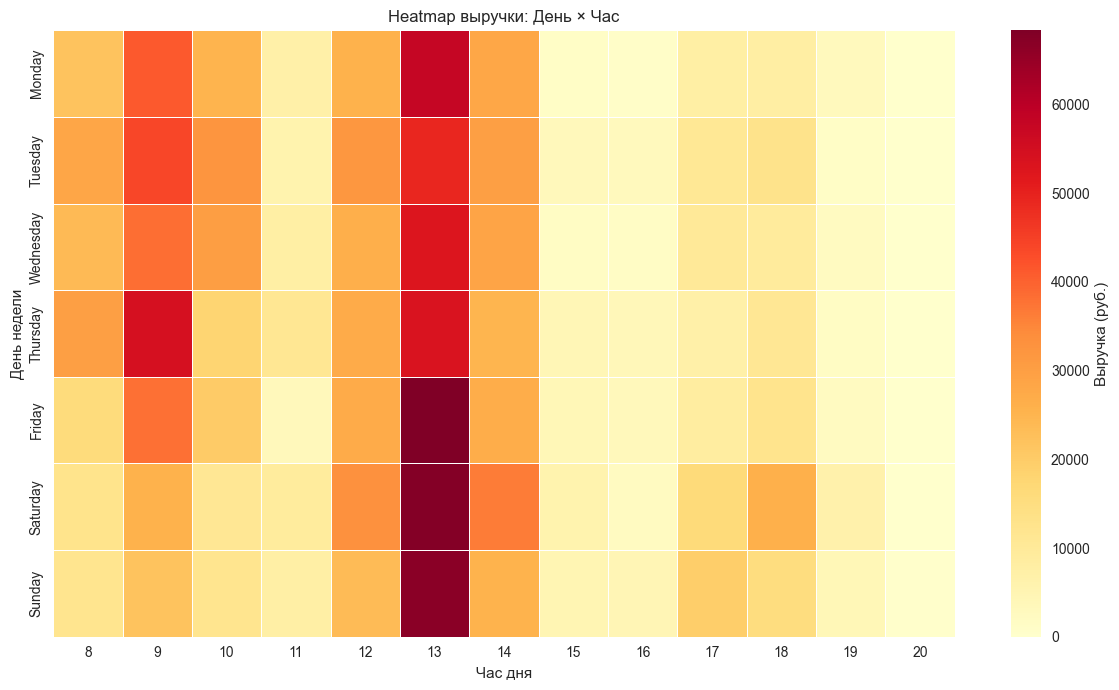

In [19]:
# Подготовка pivot
heatmap_data = df_tx.groupby(['day_name', 'hour'])['total_cost'].sum().unstack(fill_value=0)

# Порядок дней
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Выручка (руб.)'}, linewidths=0.5)
plt.title('Heatmap выручки: День × Час')
plt.xlabel('Час дня')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

#### 8. Распределение заказов по количеству напитков

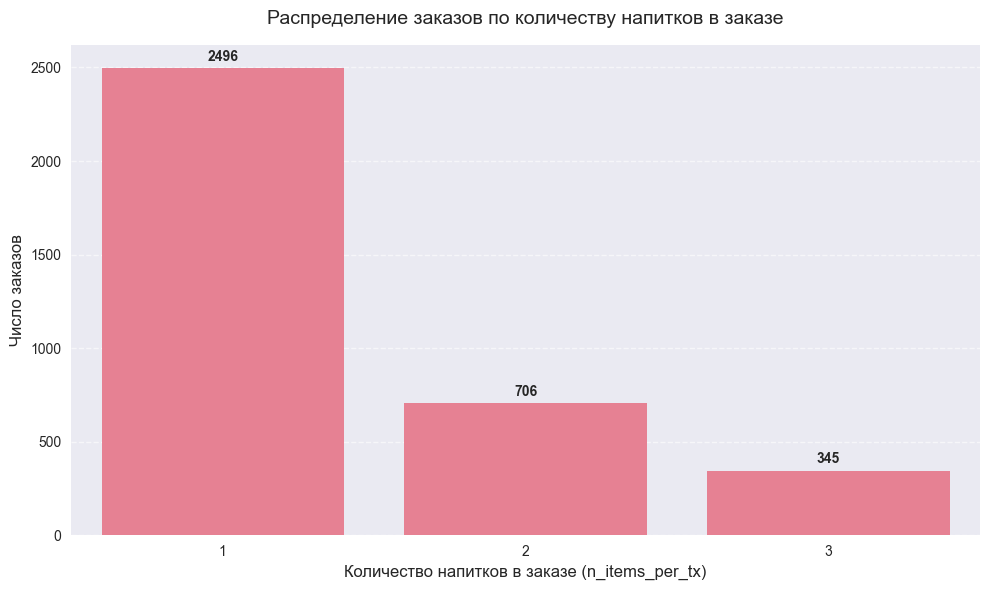


Распределение заказов по количеству напитков:
 n_items  orders_count  percent  cumulative_percent
       1          2496    70.37               70.37
       2           706    19.90               90.27
       3           345     9.73              100.00


In [20]:
# Добавляем n_items_per_tx
if 'n_items_per_tx' not in df.columns:
    df['n_items_per_tx'] = df.groupby('transaction_id').transform('size')

n_items_per_order = df.drop_duplicates('transaction_id')['n_items_per_tx']

dist = n_items_per_order.value_counts().sort_index()

# Таблица
orders_dist = dist.reset_index()
orders_dist.columns = ['n_items', 'orders_count']

# Проценты и накопленный %
total_orders = orders_dist['orders_count'].sum()
orders_dist['percent'] = (orders_dist['orders_count'] / total_orders * 100).round(2)
orders_dist['cumulative_percent'] = orders_dist['percent'].cumsum().round(2)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    data=orders_dist,
    x='n_items',
    y='orders_count',
    ax=ax,
    errorbar=None
)

# Подписи на столбцах
for p in bars.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + max(orders_dist['orders_count']) * 0.01,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Распределение заказов по количеству напитков в заказе', fontsize=14, pad=15)
ax.set_xlabel('Количество напитков в заказе (n_items_per_tx)', fontsize=12)
ax.set_ylabel('Число заказов', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, ax=ax)
plt.tight_layout()
plt.show()

# 4. Вывод таблицы
print("\nРаспределение заказов по количеству напитков:")
print(orders_dist.to_string(index=False))

In [21]:
order_sizes = df['transaction_id'].value_counts()
print(f"Всего уникальных заказов: {len(order_sizes)}")
print(f"Минимум: {order_sizes.min()}")
print(f"Максимум: {order_sizes.max()}")
print(f"Среднее: {order_sizes.mean():.2f}")
print(f"Медиана: {order_sizes.median():.1f}")
print(f"Мода: {order_sizes.mode().iloc[0]}")
print(f"\nДоля заказов ровно на 1 напиток: {(order_sizes == 1).mean():.1%}")

Всего уникальных заказов: 3547
Минимум: 1
Максимум: 3
Среднее: 1.39
Медиана: 1.0
Мода: 1

Доля заказов ровно на 1 напиток: 70.4%


#### 9. Методы оплаты

In [22]:
# Статистика по оплате
# Агрегация по способу оплаты
payment_stats = df_tx.groupby('payment_method', as_index=False).agg(
    total_orders=('transaction_id', 'count'),
    revenue=('total_cost', 'sum')
)
payment_stats['percent_of_total'] = (
    100.0 * payment_stats['revenue'] / payment_stats['revenue'].sum()
).round(2)

payment_stats = payment_stats.round(2).sort_values('revenue', ascending=False)
display(payment_stats)


,payment_method,total_orders,revenue,percent_of_total
0,card,2515,1187240.0,71.18
1,cash,1032,480810.0,28.82


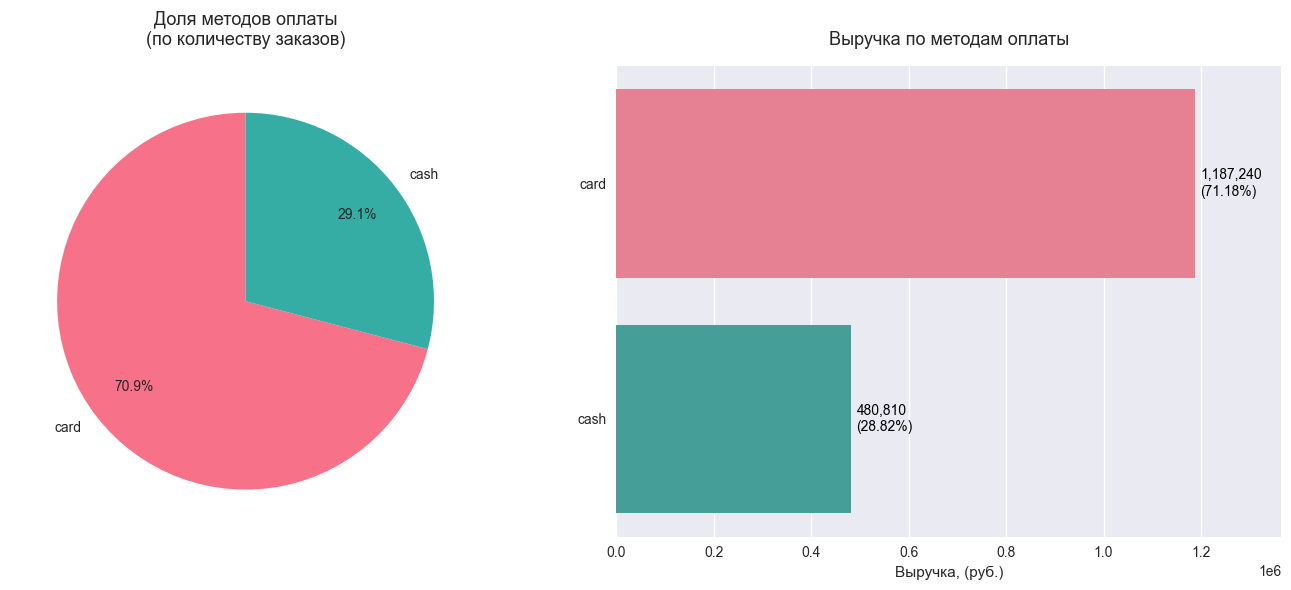


Статистика по оплате
payment_method  total_orders  total_revenue  percent_of_total
          card          2515      1187240.0             71.18
          cash          1032       480810.0             28.82


In [23]:
# Агрегация по способу оплаты
payment_stats = df_tx.groupby('payment_method', as_index=False).agg(
    total_orders=('transaction_id', 'count'),
    total_revenue=('total_cost', 'sum')
).round(2)

# Доля в общей выручке
total_revenue_all = payment_stats['total_revenue'].sum()
payment_stats['percent_of_total'] = (100 * payment_stats['total_revenue'] / total_revenue_all).round(2)

# Сортировка: по количеству заказов (для pie) — или по выручке (для bar)
payment_stats = payment_stats.sort_values('total_orders', ascending=False).reset_index(drop=True)

# 3. Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: доля по количеству транзакций
colors = sns.color_palette("husl", n_colors=len(payment_stats))
ax1.pie(
    payment_stats['total_orders'],
    labels=payment_stats['payment_method'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
ax1.set_title('Доля методов оплаты\n(по количеству заказов)', fontsize=13, pad=15)

# Bar chart: выручка
sns.barplot(
    data=payment_stats,
    x='total_revenue',
    y='payment_method',
    hue='payment_method',
    palette="husl",
    dodge=False,
    legend=False,
    ax=ax2
)
ax2.set_title('Выручка по методам оплаты', fontsize=13, pad=15)
ax2.set_xlabel('Выручка, (руб.)', fontsize=11)
ax2.set_ylabel('')

max_revenue = payment_stats['total_revenue'].max()
ax2.set_xlim(0, max_revenue * 1.15)  # ось на 15% справа

# Добавим значения на бары 
for i, row in payment_stats.iterrows():
    ax2.text(
        row['total_revenue'] + max_revenue * 0.01,  # Используем предвычисленное значение
        i,
        f"{int(row['total_revenue']):,}\n({row['percent_of_total']}%)",
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

# 4. Таблица для отчёта
print("\nСтатистика по оплате")
print(payment_stats[['payment_method', 'total_orders', 'total_revenue', 'percent_of_total', ]].to_string(index=False))

#### 10. Анализ клиентов (топ-клиенты по тратам)

             total_spent  num_transactions  avg_check
customer_id                                          
CUST_7393         2980.0                 4     745.00
CUST_9122         2640.0                 4     660.00
CUST_1235         2600.0                 3     866.67
CUST_6224         2420.0                 3     806.67
CUST_1726         2400.0                 3     800.00
CUST_7773         2220.0                 3     740.00
CUST_8554         2220.0                 2    1110.00
CUST_6489         2200.0                 3     733.33
CUST_8852         2140.0                 3     713.33
CUST_4168         2140.0                 4     535.00


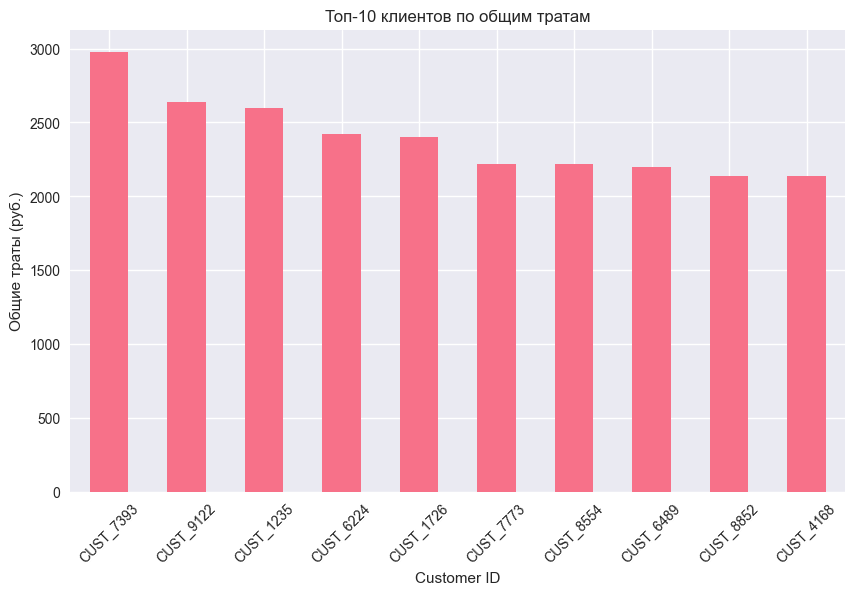

In [24]:
# Топ-10 клиентов по общим тратам
df_tx = df.groupby('transaction_id').first()[['customer_id', 'total_cost']].reset_index()

# Агрегируем по клиентам
customer_spend = (
    df_tx
    .groupby('customer_id', as_index=True)
    .agg(
        total_spent=('total_cost', 'sum'),
        num_transactions=('total_cost', 'size'),
        avg_check=('total_cost', 'mean')
    )
    .round(2)
    .sort_values('total_spent', ascending=False)
    .head(10)
)

print(customer_spend)

# Визуализация
customer_spend['total_spent'].plot(kind='bar', figsize=(10, 6))
plt.title('Топ-10 клиентов по общим тратам')
plt.xlabel('Customer ID')
plt.ylabel('Общие траты (руб.)')
plt.xticks(rotation=45)
plt.show()

---

In [25]:
# Фильтрация и извлечение
outside_rows = df[df['time_of_day'] == 'Outside hours']

# Проверка количества строк
print(f"Количество строк: {len(outside_rows)}")

# Вывод полной строки (или всех, если несколько)
if len(outside_rows) > 0:
    print(outside_rows.to_string(index=False))
else:
    print("Стpriроки не найдены.")


Количество строк: 1
transaction_id customer_id  sale_date sale_time  day_of_week day_name  is_weekend    coffee_name  drink_price  total_cost payment_method            datetime   time_of_day  month  hour       date  n_items_per_tx
       TX_1992   CUST_8992 2025-09-07  20:00:10            7   Sunday        True Latte with add        440.0       440.0           card 2025-09-07 20:00:10 Outside hours      9    20 2025-09-07               1


#### Запросы для PostgreSQL

*`sql/sales/extract_data.sql`*

**Исследуем ключевые аспекты работы кофейни (поиск инсайтов):**
*   Динамика заказов: интенсивность и распределение потока. (Пики и провалы, планирование графика).
*   Продуктовая матрица: структура и популярность товаров. (Что продаётся лучше? Оптимизация ассортимента).
*   Лояльность клиентов: паттерны повторных посещений. (Как часто возвращаются? Постоянная аудитория, retention)
*   Операционная эффективность: производительность в течение дня. (Нагрузка по дням/часам).
*    Бизнес-закономерности: выявление скрытых взаимосвязей.